In [ ]:
# @title Install
!pip install ultralytics opencv-python pillow matplotlib pytesseract moviepy nudenet transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 60.4 MB/s eta 0:00:00


In [ ]:
# @title Imports
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pytesseract
from moviepy.editor import VideoFileClip
from nudenet import NudeDetector
from transformers import pipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
# @title Loading models
#  MY FINETUNED YOLO MODEL
yolo_model = YOLO("best.pt")

# Nudity detection
nude_model = NudeDetector()

# Text understanding (offline)
classifier = pipeline("text-classification", model="unitary/toxic-bert")

The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# @title Text Detection
def detect_text(text):
    if text.strip() == "":
        return "SAFE", 0.0

    result = classifier(text)[0]
    score = result['score']

    if score > 0.7:
        return "HIGH", score
    elif score > 0.4:
        return "MEDIUM", score
    else:
        return "SAFE", score

In [ ]:
# @title Text remediation
def mask_text(text):
    words = text.split()
    masked_words = []

    for word in words:
        result = classifier(word)[0]

        if result['score'] > 0.4:
            masked_words.append("*" * len(word))
        else:
            masked_words.append(word)

    return " ".join(masked_words)

In [ ]:
# @title part of text pipeline
def process_text(text):

    level, score = detect_text(text)

    if level == "SAFE":
        return {
            "original": text,
            "remediated": text,
            "level": level
        }

    safe_text = mask_text(text)

    return {
        "original": text,
        "remediated": safe_text,
        "level": level
    }

In [ ]:
# @title Testing outputs for text
test_sentences = [
    "I hate you",
    "I will kill you",
    "You are stupid",
    "Have a nice day",
    "I want to harm myself",
    "I like you somewhat",
    "I will fuck you",
    "Shut up! you are mother fucker!",
    "I will lick your ass",
    "you are mad",
    "I want to suicide",
    "You are assole"

]

for text in test_sentences:
    result = process_text(text)

    print("Original:", result["original"])
    print("Remediated:", result["remediated"])
    print("Level:", result["level"])
    print("-"*40)

Original: I hate you
Remediated: I **** you
Level: HIGH
----------------------------------------
Original: I will kill you
Remediated: I will **** you
Level: HIGH
----------------------------------------
Original: You are stupid
Remediated: You are ******
Level: HIGH
----------------------------------------
Original: Have a nice day
Remediated: Have a nice day
Level: SAFE
----------------------------------------
Original: I want to harm myself
Remediated: I want to harm myself
Level: MEDIUM
----------------------------------------
Original: I like you somewhat
Remediated: I like you somewhat
Level: SAFE
----------------------------------------
Original: I will fuck you
Remediated: I will **** you
Level: HIGH
----------------------------------------
Original: Shut up! you are mother fucker!
Remediated: Shut up! you are mother *******
Level: HIGH
----------------------------------------
Original: I will lick your ass
Remediated: I will **** your ***
Level: HIGH
--------------------------

In [ ]:
# @title loading models again
from ultralytics import YOLO
from nudenet import NudeDetector
import cv2
import pytesseract

# ✅ your trained model
yolo_model = YOLO("best.pt")

# nudity model
nude_model = NudeDetector()

In [ ]:
import cv2
import numpy as np
import pytesseract
from ultralytics import YOLO

# --- 1. GLOBAL CONFIGURATION ---
# Set to 0.20 to catch the low-confidence detections from your custom model
YOLO_CONF = 0.20
YOLO_TARGETS = ["gun", "knife", "cigarette", "alcohol", "weapon", "pistol", "bottle", "rifle"]

NUDENET_CONF = 0.2
# We whitelist faces so NudeNet doesn't accidentally blur regular portraits
NUDENET_SAFE_CLASSES = ["FACE_FEMALE", "FACE_MALE", "FEET_EXPOSED", "ARMPITS_EXPOSED", "BELLY_EXPOSED"]

# --- 2. LOAD MODELS ---
# (Assuming you already loaded these earlier in your notebook, but here for completeness)
# yolo_model = YOLO('best.pt')
# nude_model = NudeDetector()


# --- 3. DETECTION FUNCTION ---
def detect_image_full(input_path):
    img = cv2.imread(input_path)
    if img is None:
        print("❌ Error: Image not found.")
        return {"harmful": False, "objects": [], "text": "", "text_level": "SAFE"}

    harmful = False
    detected_objects = []

    # 🔹 A. YOLO Detection
    yolo_results = yolo_model(input_path, conf=YOLO_CONF)[0]

    for box in yolo_results.boxes:
        label = yolo_model.names[int(box.cls[0])].lower()
        conf = float(box.conf[0])

        # Get exact coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Check if the label is in our target list
        is_target = any(t in label for t in YOLO_TARGETS)

        if is_target:
            harmful = True
            detected_objects.append({
                "label": label,
                "confidence": conf,
                "box": (x1, y1, x2, y2),
                "source": "YOLO"
            })

    # 🔹 B. NudeNet Detection
    nude_results = nude_model.detect(input_path)
    for res in nude_results:
        if res['class'] not in NUDENET_SAFE_CLASSES and res['score'] > NUDENET_CONF:
            harmful = True
            nx, ny, nw, nh = map(int, res['box'])
            detected_objects.append({
                "label": res['class'],
                "confidence": res['score'],
                "box": (nx, ny, nx+nw, ny+nh),
                "source": "NudeNet"
            })

    # 🔹 C. OCR Text Detection
    text = pytesseract.image_to_string(img).strip()

    # Assuming you have your custom detect_text function defined elsewhere
    try:
        level, score = detect_text(text)
    except:
        level = "SAFE" # Fallback if text logic isn't defined

    if level != "SAFE":
        harmful = True

    return {
        "harmful": harmful,
        "objects": detected_objects,
        "text": text,
        "text_level": level
    }


# --- 4. REMEDIATION FUNCTION ---
def remediate_image_full(input_path, output_path):
    # 1. Run the precise detection
    detection_data = detect_image_full(input_path)

    img = cv2.imread(input_path)
    h_img, w_img, _ = img.shape

    # 2. If nothing harmful is found, just save the original image and exit
    if not detection_data["harmful"]:
        cv2.imwrite(output_path, img)
        print("✅ Image is SAFE. No blur applied.")
        return False, detection_data["text"]

    print(f"⚠️ Harmful content found. Applying blur to {len(detection_data['objects'])} objects...")

    # 3. Apply precise blurring to ONLY the targeted objects
    for obj in detection_data["objects"]:
        x1, y1, x2, y2 = obj["box"]
        label = obj["label"]

        # Exact Coordinate Clamping (Prevents the "wrong place" or crash errors)
        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(w_img, int(x2))
        y2 = min(h_img, int(y2))

        # Define the Region of Interest (ROI)
        roi = img[y1:y2, x1:x2]

        if roi.size > 0:
            # Apply a heavy blur (99,99 is a very strong blur kernel)
            img[y1:y2, x1:x2] = cv2.GaussianBlur(roi, (99, 99), 30)
            print(f"   -> Blurred: {label} at ({x1},{y1}) to ({x2},{y2})")

    # 4. Save the final image
    cv2.imwrite(output_path, img)

    if detection_data["text_level"] != "SAFE":
        print(f"   -> Harmful text found: {detection_data['text']}")

    return True, detection_data["text"]

# --- 5. HOW TO RUN IT ---
# harmful_found, extracted_text = remediate_image_full("test1.jpg", "output_test1.jpg")

In [300]:
# @title Testing inputs
harmful, text = remediate_image_full("gun1.webp", "output.jpg")

print("Harmful:", harmful)
print("Extracted text:", text)


image 1/1 /content/gun1.webp: 640x608 1 weapon, 15.7ms
Speed: 5.3ms preprocess, 15.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 608)
⚠️ Harmful content found. Applying blur to 2 objects...
   -> Blurred: weapon at (54,78) to (103,170)
   -> Blurred: FEMALE_BREAST_COVERED at (99,171) to (144,223)
Harmful: True
Extracted text: shutterstock.com - 2287530815


(np.float64(-0.5), np.float64(258.5), np.float64(279.5), np.float64(-0.5))

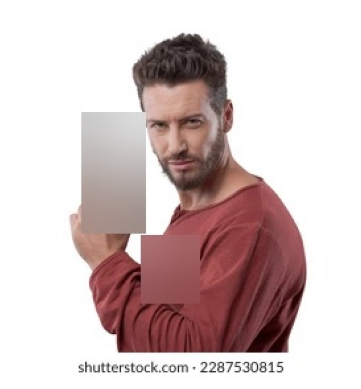

In [301]:
# @title Show Output for remediated image
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("output.jpg")
plt.imshow(img)
plt.axis('off')